<a href="https://colab.research.google.com/github/12sandra/Data-Science-Projects/blob/main/Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import(train_test_split,GridSearchCV,cross_val_score,RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import joblib
from sklearn.svm import SVC
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score

In [ ]:
file_path="/content/HR Data.xlsx - HR data.csv"
df=pd.read_csv(file_path)

In [ ]:
df.head()

,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Employee Number,Gender,Job Role,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,1,Female,Sales Executive,...,3,1,80,0,8,1,6,4,0,5
1,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,2,Male,Research Scientist,...,4,4,80,1,10,3,10,7,1,7
2,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,4,Male,Laboratory Technician,...,3,2,80,0,7,3,0,0,0,0
3,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-5,5,Female,Research Scientist,...,3,3,80,0,8,3,8,7,3,0
4,No,Travel_Rarely,25 - 34,Current Employees,R&D,Medical,STAFF-7,7,Male,Laboratory Technician,...,3,4,80,1,6,3,2,2,2,2


In [ ]:
df.shape

(1470, 39)

In [ ]:
df.size

57330

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Attrition                   1470 non-null   object
 1   Business Travel             1470 non-null   object
 2   CF_age band                 1470 non-null   object
 3   CF_attrition label          1470 non-null   object
 4   Department                  1470 non-null   object
 5   Education Field             1470 non-null   object
 6   emp no                      1470 non-null   object
 7   Employee Number             1470 non-null   int64 
 8   Gender                      1470 non-null   object
 9   Job Role                    1470 non-null   object
 10  Marital Status              1470 non-null   object
 11  Over Time                   1470 non-null   object
 12  Over18                      1470 non-null   object
 13  Training Times Last Year    1470 non-null   int6

In [ ]:
df.describe()

,Employee Number,Training Times Last Year,Age,CF_current Employee,Daily Rate,Distance From Home,Employee Count,Environment Satisfaction,Hourly Rate,Job Involvement,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,1024.865306,2.799320,36.923810,0.838776,802.485714,9.192517,1.0,2.721769,65.891156,2.729932,...,3.153741,2.712245,80.0,0.793878,11.279592,2.761224,7.008163,4.229252,2.187755,4.123129
std,602.024335,1.289271,9.135373,0.367863,403.509100,8.106864,0.0,1.093082,20.329428,0.711561,...,0.360824,1.081209,0.0,0.852077,7.780782,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,0.000000,18.000000,0.000000,102.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,3.000000,1.000000,80.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,491.250000,2.000000,30.000000,1.000000,465.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,1020.500000,3.000000,36.000000,1.000000,802.000000,7.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1555.750000,3.000000,43.000000,1.000000,1157.000000,14.000000,1.0,4.000000,83.750000,3.000000,...,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,2068.000000,6.000000,60.000000,1.000000,1499.000000,29.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,4.000000,80.0,3.000000,40.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df.nunique()

,0
Attrition,2
Business Travel,3
CF_age band,5
CF_attrition label,2
Department,3
Education Field,6
emp no,1470
Employee Number,1470
Gender,2
Job Role,9


In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
df['Employee Count'].value_counts()

,count
Employee Count,
1,1470


In [ ]:
df['Standard Hours'].value_counts()

,count
Standard Hours,
80,1470


In [ ]:
df['Over18'].value_counts()

,count
Over18,
Y,1470


<Axes: xlabel='Attrition', ylabel='count'>

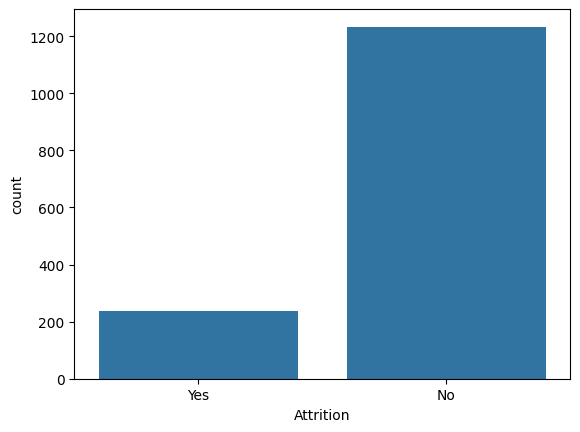

In [ ]:
sns.countplot(x='Attrition',data=df)

In [ ]:

num_cols = df.select_dtypes(include=['int64'])
cat_cols=df.select_dtypes(include=['object'])

In [ ]:
df.isnull().sum()

,0
Attrition,0
Business Travel,0
CF_age band,0
CF_attrition label,0
Department,0
Education Field,0
emp no,0
Employee Number,0
Gender,0
Job Role,0


In [ ]:
df.drop('emp no',axis=1,inplace=True)
df.drop('Employee Number',axis=1,inplace=True)
df.drop('Employee Count',axis=1,inplace=True)
df.drop('Standard Hours',axis=1,inplace=True)


In [ ]:
df.shape

(1470, 35)

In [ ]:

df.drop('Over18',axis=1,inplace=True)

In [ ]:
df['Attrition']=df['Attrition'].map({'Yes':1,'No':0})

In [ ]:
correlation=df.corr(numeric_only=True)['Attrition'].sort_values(ascending=False)

In [ ]:
print(correlation)

Attrition                     1.000000
Distance From Home            0.077924
Num Companies Worked          0.043494
Monthly Rate                  0.015170
Performance Rating            0.002889
Hourly Rate                  -0.006846
Percent Salary Hike          -0.013478
Years Since Last Promotion   -0.033019
Relationship Satisfaction    -0.045872
Daily Rate                   -0.056652
Training Times Last Year     -0.059478
Work Life Balance            -0.063939
Environment Satisfaction     -0.103369
Job Satisfaction             -0.103481
Job Involvement              -0.130016
Years At Company             -0.134392
Stock Option Level           -0.137145
Years With Curr Manager      -0.156199
Age                          -0.159205
Monthly Income               -0.159840
Years In Current Role        -0.160545
Job Level                    -0.169105
Total Working Years          -0.171063
CF_current Employee          -1.000000
Name: Attrition, dtype: float64


In [ ]:
df.drop('Monthly Rate',axis=1,inplace=True)
df.drop('Performance Rating',axis=1,inplace=True)
df.drop('Hourly Rate',axis=1,inplace=True)
df.drop('Percent Salary Hike',axis=1,inplace=True)

In [ ]:
print(df.duplicated().sum())

0


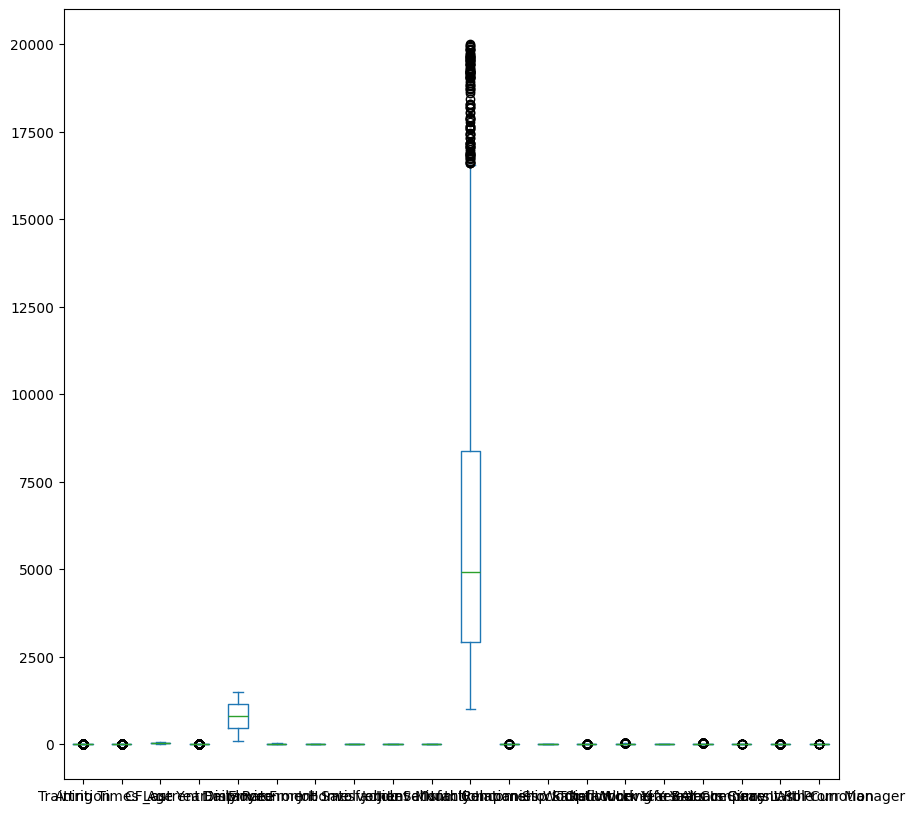

In [ ]:
data=df.plot(kind='box',figsize=(10,10))

In [ ]:

num_cols = df.select_dtypes(include=['int64'])
cat_cols=df.select_dtypes(include=['object'])

In [ ]:
cat_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Business Travel     1470 non-null   object
 1   CF_age band         1470 non-null   object
 2   CF_attrition label  1470 non-null   object
 3   Department          1470 non-null   object
 4   Education Field     1470 non-null   object
 5   Gender              1470 non-null   object
 6   Job Role            1470 non-null   object
 7   Marital Status      1470 non-null   object
 8   Over Time           1470 non-null   object
 9   Education           1470 non-null   object
dtypes: object(10)
memory usage: 115.0+ KB


In [ ]:
num_cols=num_cols.drop('Attrition',axis=1)

In [ ]:
q1=num_cols.quantile(.25)
q3=num_cols.quantile(.75)
iqr=q3-q1

df[num_cols.columns]=num_cols.clip(
    lower=q1-(1.5*iqr),
    upper=q3+(1.5*iqr),
    axis=1

)

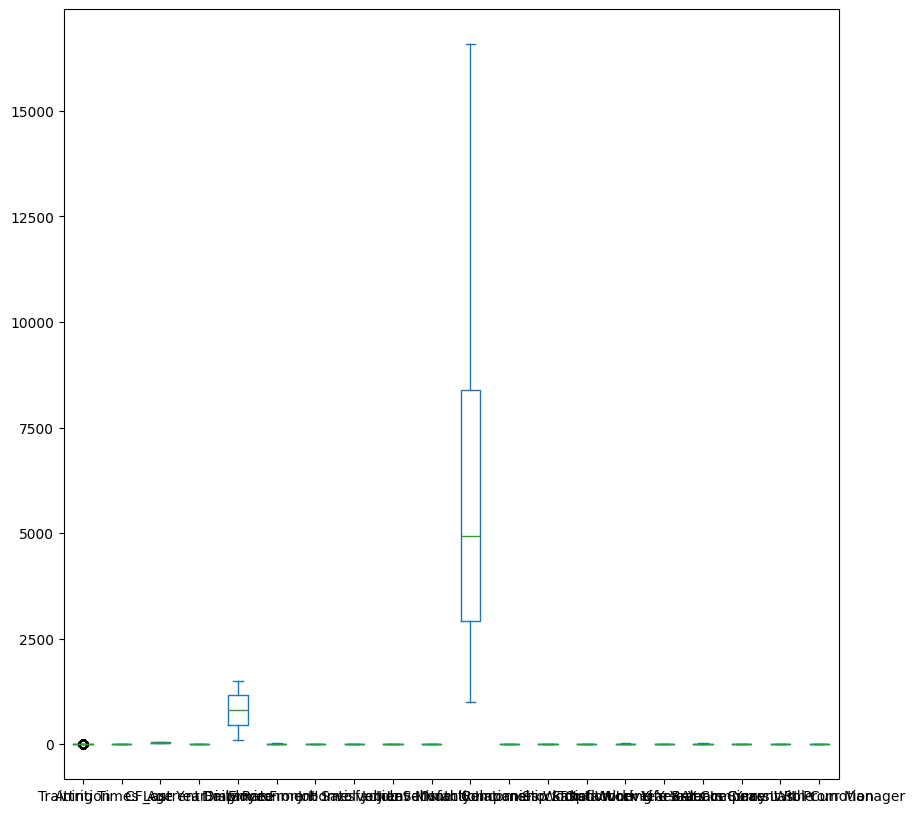

In [ ]:
data=df.plot(kind='box',figsize=(10,10))

In [ ]:
df=pd.get_dummies(df,drop_first=True,dtype=int)

In [ ]:
df = df.drop(['CF_attrition label_Ex-Employees', 'CF_current Employee'], axis=1)

In [ ]:
X=df.drop('Attrition',axis=1)
y=df['Attrition']

In [ ]:
columns=X.columns
joblib.dump(columns,"columns.pkl")

['columns.pkl']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
sscaler=StandardScaler()
df[num_cols.columns]=sscaler.fit_transform(num_cols)

In [ ]:
joblib.dump(sscaler,"scaler.pkl")

['scaler.pkl']

In [ ]:
model_lr=LogisticRegression(class_weight='balanced')
model_lr.fit(X_train,y_train)
y_pred_lr=model_lr.predict(X_test)
acc_lr=accuracy_score(y_test,y_pred_lr)
prec_lr=precision_score(y_test,y_pred_lr)
print(classification_report(y_test,y_pred_lr))
print("recall",recall_score(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.61      0.72       247
           1       0.23      0.60      0.33        47

    accuracy                           0.61       294
   macro avg       0.56      0.60      0.53       294
weighted avg       0.78      0.61      0.66       294

recall 0.5957446808510638


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print(acc_lr)
print(prec_lr)

0.608843537414966
0.22580645161290322


In [ ]:
model_rf=RandomForestClassifier(n_estimators=100,class_weight='balanced')
model_rf.fit(X_train,y_train)
y_pred_rf=model_rf.predict(X_test)
acc_rf=accuracy_score(y_test,y_pred_rf)
print("accuracy",acc_rf)
print(classification_report(y_test,y_pred_rf))
print("recall",recall_score(y_test,y_pred_rf))

accuracy 0.8469387755102041
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       247
           1       0.60      0.13      0.21        47

    accuracy                           0.85       294
   macro avg       0.73      0.56      0.56       294
weighted avg       0.81      0.85      0.80       294

recall 0.1276595744680851


In [ ]:
model_nb=GaussianNB()
model_nb.fit(X_train,y_train)
y_pred_nb=model_nb.predict(X_test)
acc_nb=accuracy_score(y_test,y_pred_nb)
print("accuracy",acc_nb)
print(classification_report(y_test,y_pred_nb))
print("recall",recall_score(y_test,y_pred_nb))

accuracy 0.7006802721088435
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       247
           1       0.30      0.64      0.41        47

    accuracy                           0.70       294
   macro avg       0.60      0.68      0.60       294
weighted avg       0.81      0.70      0.74       294

recall 0.6382978723404256


In [ ]:
model_knn=KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train,y_train)
y_pred_knn=model_knn.predict(X_test)
acc_knn=accuracy_score(y_test,y_pred_knn)
print("accuracy",acc_knn)
print(classification_report(y_test,y_pred_knn))
print("recall",recall_score(y_test,y_pred_knn))

accuracy 0.8129251700680272
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       247
           1       0.17      0.04      0.07        47

    accuracy                           0.81       294
   macro avg       0.50      0.50      0.48       294
weighted avg       0.73      0.81      0.76       294

recall 0.0425531914893617


In [ ]:
model_svc=SVC(kernel='rbf',C=1.0,gamma='scale',class_weight='balanced')
model_svc.fit(X_train,y_train)
y_pred_svc=model_svc.predict(X_test)
acc_svc=accuracy_score(y_test,y_pred_svc)
print("accuracy",acc_svc)
print(classification_report(y_test,y_pred_svc))
print("recall",recall_score(y_test,y_pred_svc))

accuracy 0.6360544217687075
              precision    recall  f1-score   support

           0       0.90      0.64      0.75       247
           1       0.25      0.62      0.35        47

    accuracy                           0.64       294
   macro avg       0.57      0.63      0.55       294
weighted avg       0.79      0.64      0.68       294

recall 0.6170212765957447


In [ ]:

model_xgb=XGBClassifier(n_estimators=100,max_depth=5,random_state=42,class_weight='balanced')
model_xgb.fit(X_train,y_train)
y_pred_xgb=model_xgb.predict(X_test)
acc_xgb=accuracy_score(y_test,y_pred_xgb)
print("accuracy",acc_xgb)
print(classification_report(y_test,y_pred_xgb))
print("recall",recall_score(y_test,y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:09:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy 0.8809523809523809
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       247
           1       0.71      0.43      0.53        47

    accuracy                           0.88       294
   macro avg       0.81      0.70      0.73       294
weighted avg       0.87      0.88      0.87       294

recall 0.425531914893617


In [ ]:
param_grid = {
    'var_smoothing': [1e-9,1e-8,1e-7,1e-6,1e-5]
}

grid = GridSearchCV(model_nb, param_grid, cv=5, scoring='recall')

grid.fit(X_train, y_train)

print("Best parameter:", grid.best_params_)
print("Best score:", grid.best_score_)

Best parameter: {'var_smoothing': 1e-09}
Best score: 0.6157894736842106


In [ ]:
cv_scores=cross_val_score(model_svc,X,y,cv=5)
print("cv scores : ",cv_scores.mean())

cv scores :  0.6727891156462584


In [ ]:
param_grid={
    'kernel':['rbf','linear'],
    'C':[0.1,1.0,10],
    'gamma':['scale','auto']
}
grid=GridSearchCV(SVC(),param_grid,cv=5)
grid.fit(X_train,y_train)
print("Best parameters : ",grid.best_params_)
print("Best scores: ",grid.best_score_)

KeyboardInterrupt: 

In [ ]:
param_dist = {
    'kernel': ['rbf','linear'],
    'C': [0.1,1.0,10],
    'gamma': ['scale','auto']
}

random = RandomizedSearchCV(
    SVC(),
    param_distributions=param_dist,
    n_iter=6,        # number of combinations to try
    cv=5,
    random_state=42
)

random.fit(X_train,y_train)

print("Best parameters:", random.best_params_)
print("Best score:", random.best_score_)

Best parameters: {'kernel': 'linear', 'gamma': 'scale', 'C': 10}
Best score: 0.8715975477821853


In [ ]:
best_svc=random.best_estimator_

In [ ]:
joblib.dump(best_svc,"model")

['model']

In [ ]:
print(df.corr()['Attrition'].sort_values(ascending=False))